In [1]:
# Install required library
!pip install beautifulsoup4 requests

# Import libraries
import requests
from bs4 import BeautifulSoup
import pandas as pd

print("Libraries imported!")

Libraries imported!


In [2]:
# Connect to Books to Scrape website
url = "http://books.toscrape.com/"
response = requests.get(url)

print("Status Code:", response.status_code)
print("Connected Successfully!" if response.status_code == 200 else "Connection Failed!")

Status Code: 200
Connected Successfully!


In [3]:
# Parse the HTML content
soup = BeautifulSoup(response.content, 'html.parser')
print("Page parsed successfully!")
print("Page Title:", soup.title.text)

Page parsed successfully!
Page Title: 
    All products | Books to Scrape - Sandbox



In [4]:
# Find all books on the page
books = soup.find_all('article', class_='product_pod')
print("Number of books found:", len(books))

Number of books found: 20


In [5]:
# Extract title, price and rating
book_list = []

for book in books:
    title = book.h3.a['title']
    price = book.find('p', class_='price_color').text
    rating = book.find('p', class_='star-rating')['class'][1]

    book_list.append({
        'Title': title,
        'Price': price,
        'Rating': rating
    })

print("Books extracted:", len(book_list))

Books extracted: 20


In [6]:
# Convert to pandas DataFrame
df = pd.DataFrame(book_list)
df.head(10)

,Title,Price,Rating
0,A Light in the Attic,£51.77,Three
1,Tipping the Velvet,£53.74,One
2,Soumission,£50.10,One
3,Sharp Objects,£47.82,Four
4,Sapiens: A Brief History of Humankind,£54.23,Five
5,The Requiem Red,£22.65,One
6,The Dirty Little Secrets of Getting Your Dream...,£33.34,Four
7,The Coming Woman: A Novel Based on the Life of...,£17.93,Three
8,The Boys in the Boat: Nine Americans and Their...,£22.60,Four
9,The Black Maria,£52.15,One


In [7]:
# Scrape all 50 pages
all_books = []

for page in range(1, 51):
    url = f"http://books.toscrape.com/catalogue/page-{page}.html"
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')
    books = soup.find_all('article', class_='product_pod')

    for book in books:
        title = book.h3.a['title']
        price = book.find('p', class_='price_color').text
        rating = book.find('p', class_='star-rating')['class'][1]

        all_books.append({
            'Title': title,
            'Price': price,
            'Rating': rating
        })

print("Total books scraped:", len(all_books))

Total books scraped: 1000


In [8]:
# Convert to DataFrame and save
df = pd.DataFrame(all_books)
df.to_csv('scraped_books.csv', index=False)
print("Data saved to scraped_books.csv!")
df.head()

Data saved to scraped_books.csv!


,Title,Price,Rating
0,A Light in the Attic,£51.77,Three
1,Tipping the Velvet,£53.74,One
2,Soumission,£50.10,One
3,Sharp Objects,£47.82,Four
4,Sapiens: A Brief History of Humankind,£54.23,Five


In [9]:
# Clean price column - remove £ symbol
df['Price'] = df['Price'].str.replace('£', '').astype(float)

# Convert rating from words to numbers
rating_map = {
    'One': 1, 'Two': 2, 'Three': 3,
    'Four': 4, 'Five': 5
}
df['Rating'] = df['Rating'].map(rating_map)

print("Data cleaned!")
df.head()

Data cleaned!


,Title,Price,Rating
0,A Light in the Attic,51.77,3
1,Tipping the Velvet,53.74,1
2,Soumission,50.10,1
3,Sharp Objects,47.82,4
4,Sapiens: A Brief History of Humankind,54.23,5


In [10]:
# Basic statistics
print("Total Books:", len(df))
print("\nAverage Price: £", round(df['Price'].mean(), 2))
print("Highest Price: £", df['Price'].max())
print("Lowest Price: £", df['Price'].min())
print("\nRating Distribution:")
print(df['Rating'].value_counts().sort_index())

Total Books: 1000

Average Price: £ 35.07
Highest Price: £ 59.99
Lowest Price: £ 10.0

Rating Distribution:
Rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64


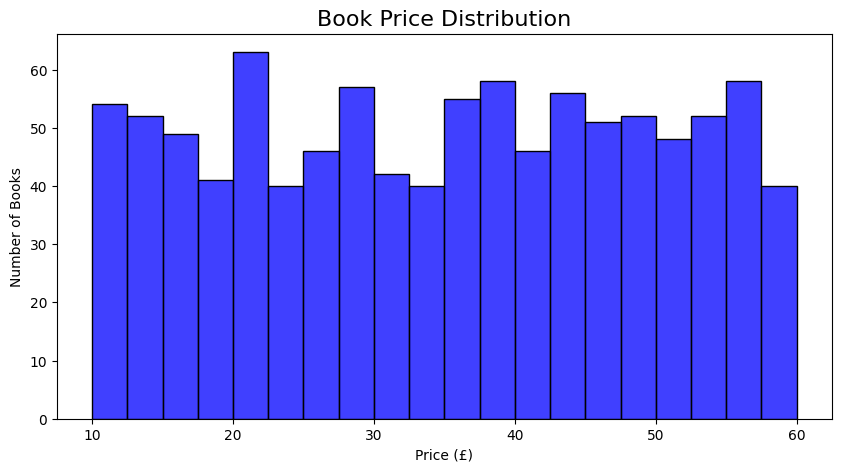

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Price distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Price'], bins=20, color='blue')
plt.title('Book Price Distribution', fontsize=16)
plt.xlabel('Price (£)')
plt.ylabel('Number of Books')
plt.savefig('price_distribution.png')
plt.show()

/tmp/ipykernel_8778/3469288245.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Rating', palette='viridis')


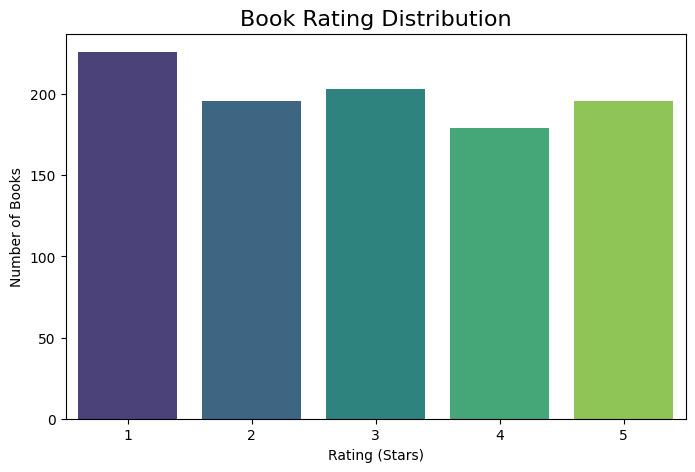

In [12]:
# Rating distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Rating', palette='viridis')
plt.title('Book Rating Distribution', fontsize=16)
plt.xlabel('Rating (Stars)')
plt.ylabel('Number of Books')
plt.savefig('rating_distribution.png')
plt.show()

In [13]:
# Download all files
from google.colab import files
files.download('scraped_books.csv')
files.download('price_distribution.png')
files.download('rating_distribution.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>